# Classificação com Árvores de Decisão

**Autor:** Geraldo Pereira Rocha Filho
**Data:** 24 de Abril de 2025

Neste notebook, vamos usar o algoritmo de Árvores de Decisão para classificar o conjunto de dados Iris. O objetivo é entender como o algoritmo funciona e como podemos avaliá-lo.

# Etapa 1: Importando bibliotecas

In [3]:
# pandas, numpy, seaborn, matplotlib.pyplot
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# sklearn.model_selection
from sklearn.model_selection import train_test_split

# sklearn.tree
# DecisionTreeClassifier
# plot_tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# sklearn.metrics
# classification_report
# confusion_matrix
# accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# sklearn.preprocessing
# LabelEncoder: converte rótulos de texto (como "setosa") em números (como 0, 1, 2)
from sklearn.preprocessing import LabelEncoder

# Etapa 2: Carregando o dataset Iris com o seaborn

In [4]:
#O seaborn já possui esse dataset pronto, com nomes organizados
df_iris = sns.load_dataset('iris')
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


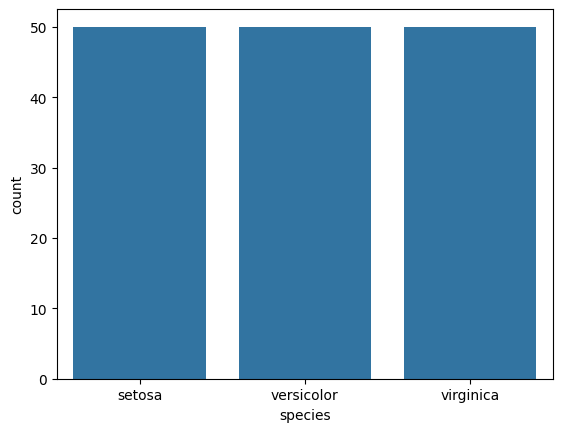

In [5]:
#Visualização da Distribuição das Classes (Espécies)
sns.countplot(x='species', data=df_iris)
plt.show()

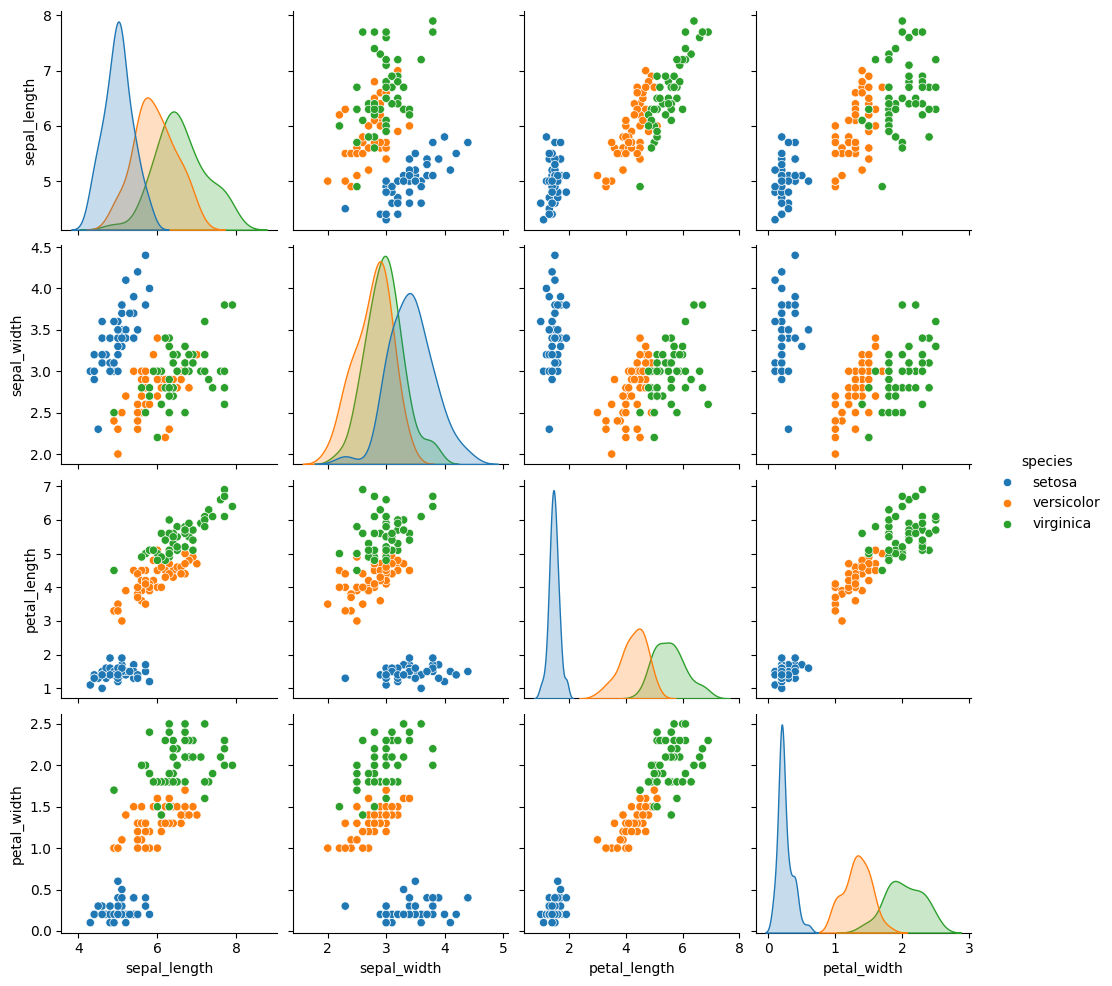

In [6]:
#Visualização da Distribuição das Classes (Espécies)
sns.pairplot(df_iris, hue='species')
plt.show()


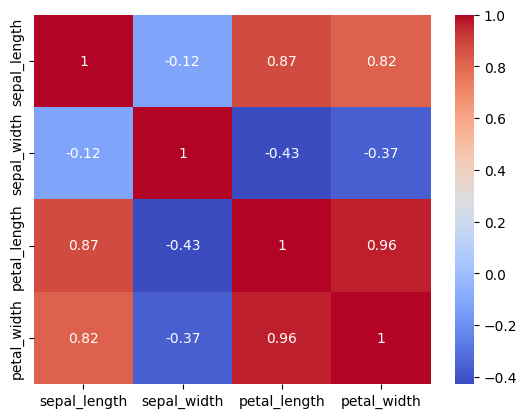

In [7]:
#Correlação entre variáveis (heatmap)
plt.figure()
sns.heatmap(df_iris.drop(columns='species').corr(), annot=True, cmap='coolwarm')
plt.show()


# Etapa 3: Verificando se há dados faltantes

In [8]:
print("\nVerificando dados ausentes:")
print(df_iris.isnull().sum())


Verificando dados ausentes:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


# Etapa 4: Entendendo o tipo de dados

In [9]:
print("\nInformações do dataset:")
df_iris.info()


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# Etapa 5: Convertendo a variável alvo ('species') em números



In [10]:
#O algoritmo de classificação precisa que os rótulos sejam numéricos
le=LabelEncoder()
df_iris['species_encoded'] = le.fit_transform(df_iris['species'])
#df_iris.iloc[95:105]

#Separando os dados em
#X -> atributos (features)
#y -> rótulo (classe que queremos prever/classificar)
X = df_iris.drop(columns=['species', 'species_encoded'])
y = df_iris['species_encoded']
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_encoded
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


# Etapa 6: Dividindo os dados em treino e teste



In [11]:
#Vamos usar 60% para treinar o modelo e 40% para testá-lo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
#45 exemplos de treino
#15 setosa
#15 Viginica
#15 Versicolor


# Etapa 7: Criando o modelo de Árvore de Decisão


In [12]:
#O modelo vai aprender as "regras" a partir dos dados de treino
clf = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

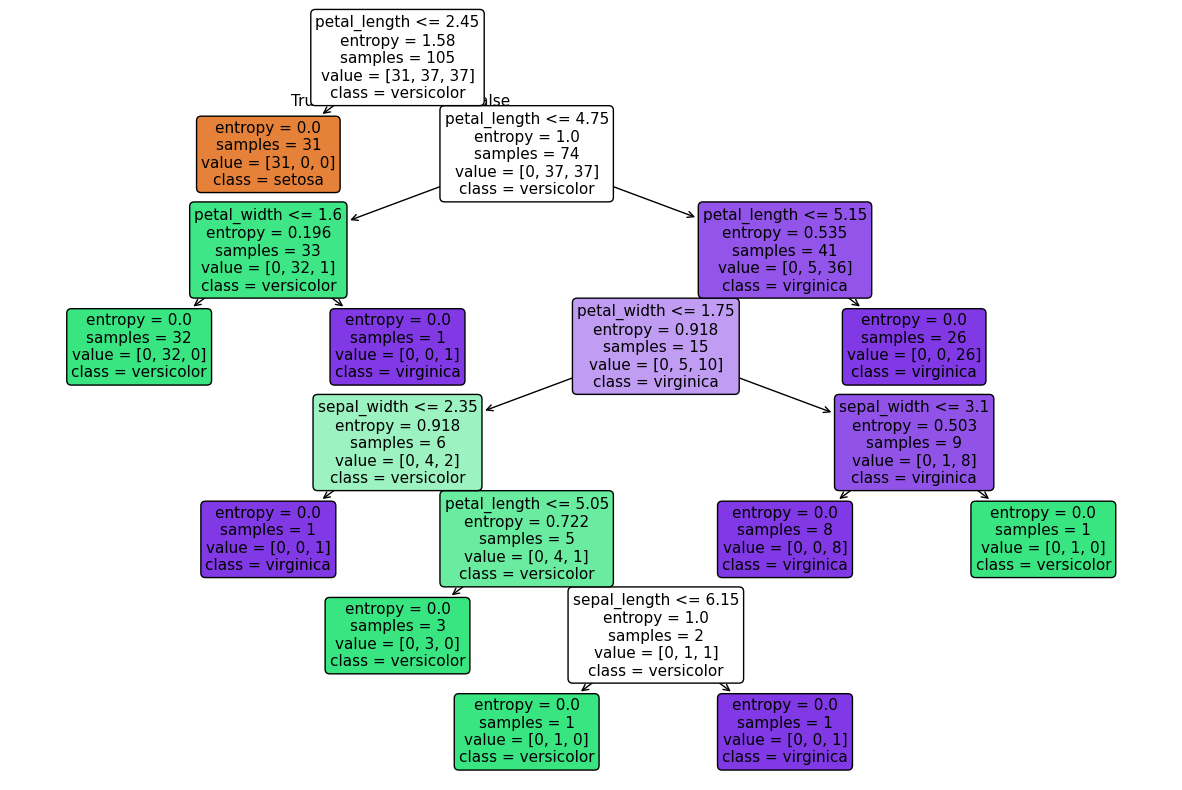

In [13]:
#Visualização da Árvore de Decisão - Dataset Iris
plt.figure(figsize=(15, 10))

plot_tree(clf, feature_names=X.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True)

plt.show()

# Etapa 8: Fazendo previsões com os dados de teste




In [14]:
#Fazer as previsões
y_pred = clf.predict(X_test)

#amostra = np.array([[3.1,2.3,1.4,0.2]])
#amostra_pred = clf.predict(amostra)
#print(le.inverse_transform(amostra_pred))

#comparar os rótulos reais e os previstos
df_resultado=pd.DataFrame({
    'Real': le.inverse_transform(y_test),
    'Previsto': le.inverse_transform(y_pred)
})

#print(df_resultado)

print(df_resultado[df_resultado['Real'] != df_resultado['Previsto']])

print(1 - 1/60)



         Real    Previsto
10  virginica  versicolor
0.9833333333333333


# Etapa 9: Avaliando o desempenho do modelo


In [15]:
print("\n Acurácia do modelo:")
print(accuracy_score(y_test, y_pred))



print("\n Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\n Relatório de Classificação:")
print(classification_report(y_test, y_pred))



 Acurácia do modelo:
0.9777777777777777

 Matriz de Confusão:
[[19  0  0]
 [ 0 13  0]
 [ 0  1 12]]

 Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

